# Week 3 Seminar 

## Questions? 

We are going to discuss noise and combining images in idealised cases

We are going to look at the steps of image processing using numpy to reveal the mathematical operations

We are going to look at image stats and what they measure - is it structure or is it noise? 


In [1]:
# Import various libraries 

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import gc                               



/Users/alec/honours-env/.venv/lib/python3.11/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)
Matplotlib is building the font cache; this may take a moment.


# Noise, not noise and standard deviation

### Let's create an 2D list / image of Gaussian random noise and display it 

In [2]:
randimage=np.random.normal(loc=0.0, scale=100.0, size=(1024,2048))  # Comment 

[[  31.47759301   87.24387505   84.99203711 ...  -84.95681019
  -169.92065553  172.93276304]
 [ -11.56374869  -81.22819805    6.48775517 ...  140.50991169
    46.35312363   39.78353722]
 [ 192.51782672 -169.0783781    32.78992695 ...   46.93906843
   -48.89074269   72.33321192]
 ...
 [ 113.61803844  -96.93929394  -25.29225119 ... -195.2882964
   -62.34692925  129.47520336]
 [  62.56159354  102.07084748  190.82033956 ...   82.59457418
     5.85672989 -229.529547  ]
 [ 103.40072207  -88.26308343 -173.60650636 ...   91.43936693
   -64.42028679  -37.88669255]]


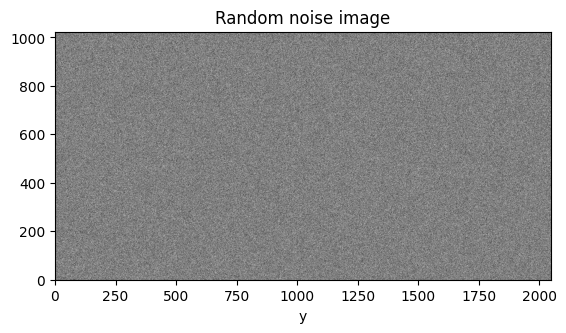

In [3]:
### Print and display the random noise 
print(randimage)

### Should be familiar now - what am I doing here?
vmin=np.nanpercentile(randimage, 1)
vmax=np.nanpercentile(randimage, 99)
plt.imshow(randimage, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
plt.title('Random noise image')
plt.xlabel('x')
plt.xlabel('y')
plt.show()


### Question: What is being plotted below?

Text(0.5, 0, 'y')

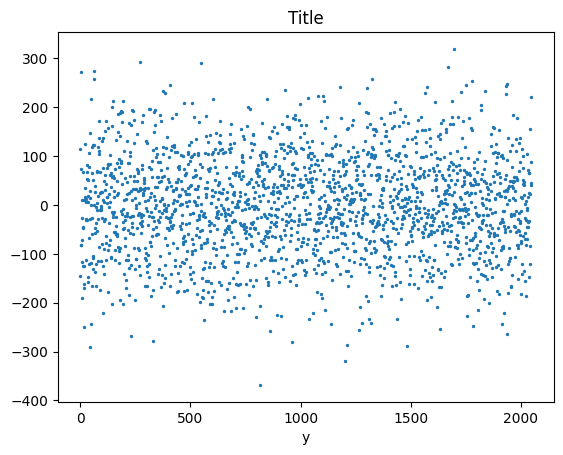

In [8]:

plx=np.linspace(0.0, len(randimage[0])-1, num=len(randimage[0])) # What is this? What does linspace do
ply=randimage[10,:]                                              # What does this correspond to?
plt.scatter(plx, ply, s=2) 
plt.title('Title')
plt.xlabel('x')
plt.xlabel('y')

### Question: Run the stats - how do they compare to expectations?

### <font color='blue'> Answer: </font>


In [10]:
print('Median :', np.nanmedian(randimage))
print('Standard deviation: ', np.std(randimage))

Median : -0.0933849620472344
Standard deviation:  100.02981196724504


In [11]:
print('Median :', np.nanmedian(randimage[0:100,0:100]))
print('Standard deviation: ', np.std(randimage[0:100,0:100]))

Median : 0.3292256869675489
Standard deviation:  99.94893179166115


### Question: Could you also estimate the standard deviation from percentiles? If so what circumstances must apply?

### <font color='blue'> Answer: </font>


In [17]:
# We want the data in the first standard deviation, ~68% of the data. Use np.percentile to take the data in by 16% from each side
vmin = np.percentile(randimage, 16)
print(f"vmin Value: {vmin:.4f}")

vmax = np.percentile(randimage, 100-16)
print(f"vmax Value: {vmax:.4f}")

perstd = 0.5*(vmax-vmin)
print(f"Percentile standard deviation: {perstd:.4f}")

vmin Value: -99.3911
vmax Value: 99.4518
Percentile standard deviation: 99.4215


### Lets create a version of the image with sorted values along the x-axis 


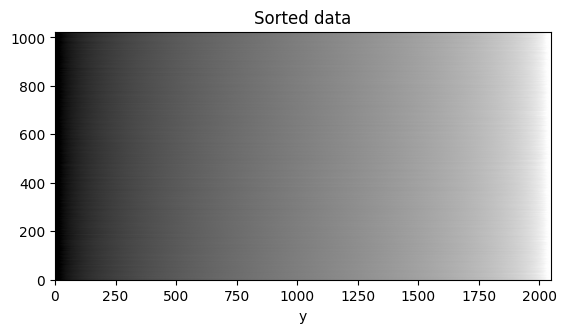

In [ ]:
sortimage=np.sort(randimage) # sort is returning a new array of all values arranged from lowest to highest
vmin=np.nanpercentile(sortimage, 1)
vmax=np.nanpercentile(sortimage, 99)

plt.imshow(sortimage, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
plt.title('Sorted data')
plt.xlabel('x')
plt.xlabel('y')
plt.show()


## Question: What is being plotted below? 

### <font color='blue'> Answer: </font>


Text(0.5, 0, 'y')

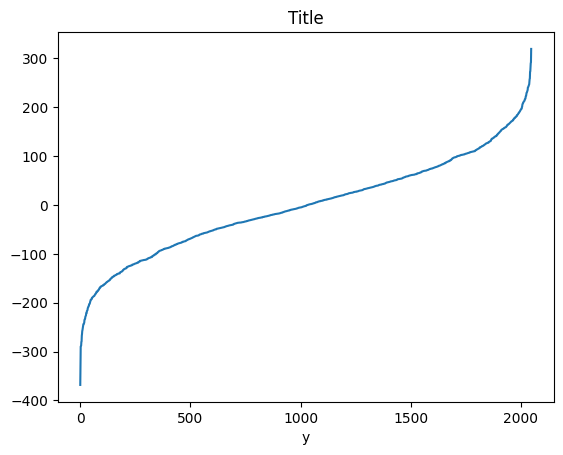

In [19]:

plx=np.linspace(0.0, len(sortimage[0])-1, num=len(sortimage[0])) # What is this? What does linspace do
ply=sortimage[10,:]                                              # What does this correspond to?
plt.plot(plx, ply) 
plt.title('Title')
plt.xlabel('x')
plt.xlabel('y')


## Question: Is the sorted image purely random noise anymore? 

### <font color='blue'> Answer: No</font>


## Question: Run the stats on the sorted image - how do they compare to what we determined earlier?

### <font color='blue'> Answer: The values are still roughly the same across the entire image. However, the subsection is very different. This is because the data is no longer random.</font>


In [24]:
print('Median :', np.nanmedian(sortimage))
print('Standard deviation: ', np.std(sortimage))

Median : -0.0933849620472344
Standard deviation:  100.02981196724504


In [23]:
print('Median :', np.nanmedian(sortimage[0:100,0:100]))
print('Standard deviation: ', np.std(sortimage[0:100,0:100]))

Median : -196.36925246794044
Standard deviation:  37.668512866686136


# Noise and combining images 

Lets create a bunch of images just containing Gaussian random noise

Lets then combine them together 


Image 0
Median : -0.04101542283662861
Standard deviation:  100.01615168530994


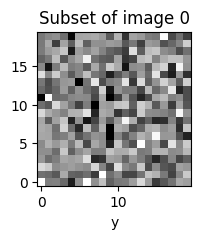

Image 1
Median : 0.016535034078421534
Standard deviation:  100.08491308423397


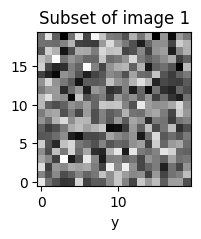

Image 2
Median : 0.030709475295975487
Standard deviation:  99.94175044604161


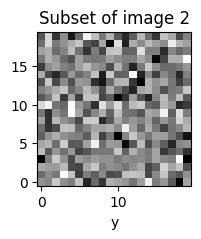

Image 3
Median : -0.11748741682941455
Standard deviation:  100.07144955383986


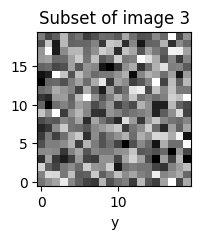

Image 4
Median : -0.1758372724332562
Standard deviation:  99.99687003829884


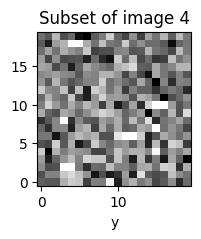

Image 5
Median : -0.10687236580572052
Standard deviation:  100.05151944967804


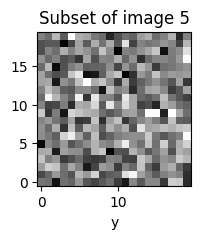

Image 6
Median : -0.064758986684914
Standard deviation:  100.13969511480576


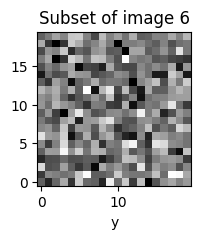

Image 7
Median : -0.1908337969530524
Standard deviation:  100.0210316273842


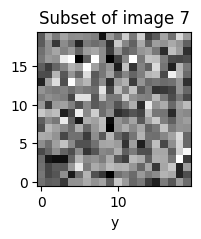

Image 8
Median : -0.10295809373745395
Standard deviation:  99.95939948647748


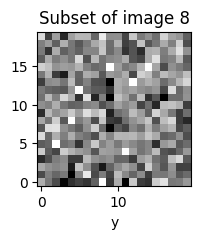

Image 9
Median : 0.024915586817809428
Standard deviation:  100.028178000168


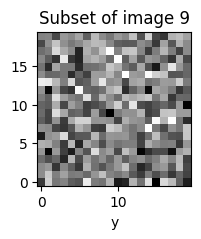

In [25]:
images = []  # empty list of images

# Create random images and add them to the list until I have 10 images
while len(images)<10:
    randimage=np.random.normal(loc=0.0, scale=100.0, size=(1024,1024))
    images.append(randimage)

vmin=np.nanpercentile(images[0], 1)
vmax=np.nanpercentile(images[0], 99)

for idx, image in enumerate(images):
    plt.rcParams["figure.figsize"] = (2,2)
    plt.imshow(image[0:20,0:20], vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
    title = 'Subset of image ' + str(idx)
    plt.title(title)
    plt.xlabel('x')
    plt.xlabel('y')
    print('Image ' + str(idx))
    print('Median :', np.nanmedian(image))
    print('Standard deviation: ', np.std(image))
    plt.show()


## Let's do combine operations in numpy 

In [26]:
# Create initial values that are just copies of the first image 
avimage = images[0].copy()
medimage = images[0].copy()

# Step through the pixels (a bit inefficient but okay)
yi=0
while yi<len(medimage):
    xi=0
    while xi<len(medimage[0]):
        t=[]
        for image in images:
            t.append(image[yi, xi])
        avimage[yi,xi]=np.nanmean(t)
        medimage[yi,xi]=np.nanmedian(t)
        xi=xi+1
    yi=yi+1

In [ ]:
## Let's do the stats and display the images 


Average
Median : -0.08950487941095772
Standard deviation:  31.625762936881475
Standard deviation * root(N):  100.00944362108142


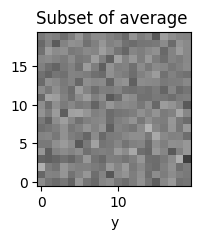

Median
Median : -0.055237453263830005
Standard deviation:  37.20889544561545
Standard deviation * root(N):  117.6648588272107


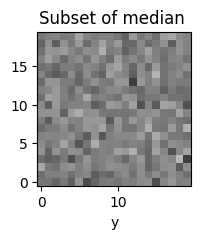

In [29]:

# Why scale to the first image in the list?
vmin=np.nanpercentile(images[0], 1)
vmax=np.nanpercentile(images[0], 99)

# Reuse code from earlier to display
image=avimage
plt.rcParams["figure.figsize"] = (2,2)
plt.imshow(image[0:20,0:20], vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Subset of average '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
print('Average')
print('Median :', np.nanmedian(image))
print('Standard deviation: ', np.std(image))
print('Standard deviation * root(N): ', np.std(image) * pow(len(images), 0.5))
plt.show()

image=medimage
plt.rcParams["figure.figsize"] = (2,2)
plt.imshow(image[0:20,0:20], vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Subset of median '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
print('Median')
print('Median :', np.nanmedian(image))
print('Standard deviation: ', np.std(image))
print('Standard deviation * root(N): ', np.std(image) * pow(len(images), 0.5))
plt.show()


## Question: How do the average and median images compare visually?

### <font color='blue'> Answer: They look pretty much the same. The pixels don't correspond to each other, but the noise is uniform in both</font>

## Question: How do the stats compare? Is there an expected value?

### <font color='blue'> Answer: </font>


# Quicker code

In [30]:
avimage_quick = np.nanmean(np.dstack(images), -1)
medimage_quick = np.nanmedian(np.dstack(images), -1)

testimage = avimage - avimage_quick
print(np.nanmin(testimage))
print(np.nanmax(testimage))

0.0
0.0


# Basic data processing as mathematical operations 

We can actually do the data processing done by ccdproc as numpy operations

Advantage is we see the operations at work directly

## Question: What could be a disadvantage of using numpy rather than ccdproc?

Here we are using fits.open to open the images 

It assumes multi-extension FITS files (i.e. lists) with our data typically at index zero

fits.open has the advantage of being a core astropy package .

fits.open can open online data and files zipped in different formats (zip, gz, bz2)


In [37]:

bias = fits.open('bias_median.fits')

dark = fits.open('dark_median.fits')

flat = fits.open('Flat_R_median.fits')

scimage = fits.open('NGC_3766_R_00004556.fits')


Average
Median : -0.055237453263830005
Standard deviation:  37.20889544561545


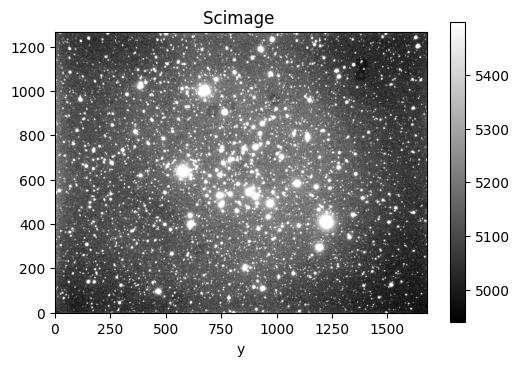

In [32]:
vmin=np.nanpercentile(scimage[0].data, 5)
vmax=np.nanpercentile(scimage[0].data, 95)
plt.rcParams["figure.figsize"] = (6,6)
plt.imshow(scimage[0].data, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Scimage '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=0.65)
print('Average')
print('Median :', np.nanmedian(image))
print('Standard deviation: ', np.std(image))
plt.show()


## Lets step through the data processing with bias subtraction


Average
Median : 3123.0
Standard deviation:  2238.6733


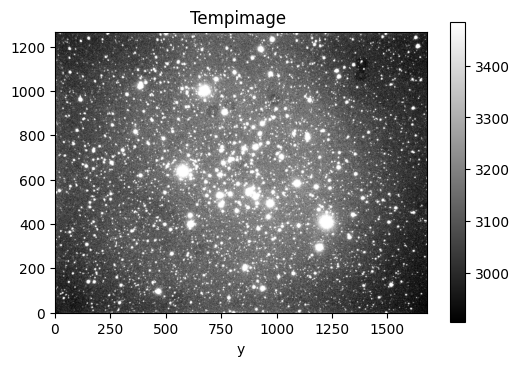

In [38]:
tempimage=scimage[0].copy()  # Copying the image data into a new variable

# Bias subtraction - am I doing it right?
tempimage.data = tempimage.data - bias[0].data

vmin=np.nanpercentile(tempimage.data, 5)
vmax=np.nanpercentile(tempimage.data, 95)
plt.rcParams["figure.figsize"] = (6,6)
plt.imshow(tempimage.data, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Tempimage '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=0.65)
print('Average')
print('Median :', np.nanmedian(tempimage.data))
print('Standard deviation: ', np.std(tempimage.data))
plt.show()


### Question: Has the bias subtraction worked? How do the numbers compare with expectation?

### <font color='blue'> Answer: Yes. We can see on the colorbar it has dropped by roughly 2000 adu. The stats are also different.</font>


In [ ]:
## Lets step through the data processing with dark subtraction


Average
Median : 3109.7666
Standard deviation:  2237.5486


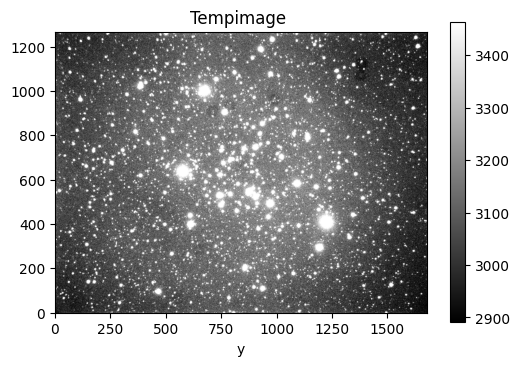

In [39]:
# Dark subtraction - am I doing it right?
tempimage.data = tempimage.data - dark[0].data * tempimage.header['EXPTIME']/dark[0].header['EXPTIME']

vmin=np.nanpercentile(tempimage.data, 5)
vmax=np.nanpercentile(tempimage.data, 95)
plt.rcParams["figure.figsize"] = (6,6)
plt.imshow(tempimage.data, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Tempimage '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=0.65)
print('Average')
print('Median :', np.nanmedian(tempimage.data))
print('Standard deviation: ', np.std(tempimage.data))
plt.show()


### Question: Has the dark subtraction worked? How do the numbers compare with expectation?

### <font color='blue'> Answer: </font>


### Lets do the flat field correction

### Question: We normalise the flat - why do we do that? 

### <font color='blue'> Answer: </font>


Average
Median : -0.055237453263830005
Standard deviation:  37.20889544561545


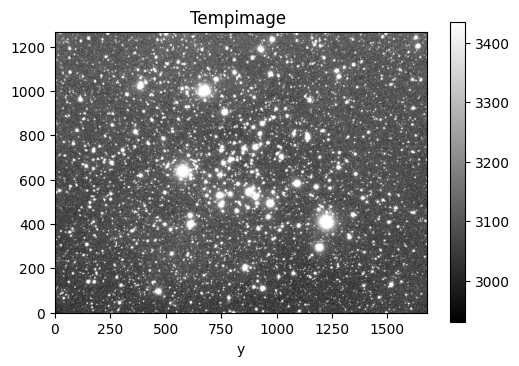

In [40]:
# Flat - am I doing it right
tempimage.data = tempimage.data / flat[0].data 

vmin=np.nanpercentile(tempimage.data, 5)
vmax=np.nanpercentile(tempimage.data, 95)
plt.rcParams["figure.figsize"] = (6,6)
plt.imshow(tempimage.data, vmin=vmin, vmax=vmax, cmap='gray', origin='lower')
title = 'Tempimage '
plt.title(title)
plt.xlabel('x')
plt.xlabel('y')
plt.colorbar(shrink=0.65)
print('Average')
print('Median :', np.nanmedian(image))
print('Standard deviation: ', np.std(image))
plt.show()

# Callback - stats, biases and flats 

## Question: How could we visually look at what are the stats of the bias and flat measuring?


In [41]:
bias.close()
dark.close()
flat.close()
scimage.close()


